
DIAGNOSTIC DU DATASET: tworoom.h5

INSPECTION DU FICHIER HDF5 BRUT

Clés du HDF5: ['action', 'distance_to_target', 'ep_idx', 'ep_len', 'ep_offset', 'id', 'observation', 'pixels', 'pos_agent', 'pos_target', 'proprio', 'render_time', 'reward', 'step_idx', 'terminated', 'truncated']

Pixels:
  Shape: (920809, 224, 224, 3), dtype: uint8
  Image 0: shape (224, 224, 3), dtype uint8
  Image 0 min/max: 0 / 255

Actions:
  Shape: (920809, 2), dtype: float32
  Min: nan, Max: nan
  NaN: True, Inf: False
    → NaN count: 20000, Inf count: 0

Episodes:
  Index range: 0-9999
  Nombre d'épisodes uniques: 10000

Longueur des épisodes:
  Min: 31, Max: 101, Mean: 92.1

VÉRIFICATION DE COHÉRENCE
[Dataset] 10000 pas de temps avec actions NaN/inf (1.09%)
[Dataset] 88081 fenêtres valides

Test de 50 échantillons aléatoires...
✓ Tous les 50 échantillons OK

Statistiques globales du dataset:
  Taille: 88081 fenêtres
  Taille brute HDF5: 920809 pas de temps
  Actions NaN/inf: 10000 / 920809
  Fenêtres valides

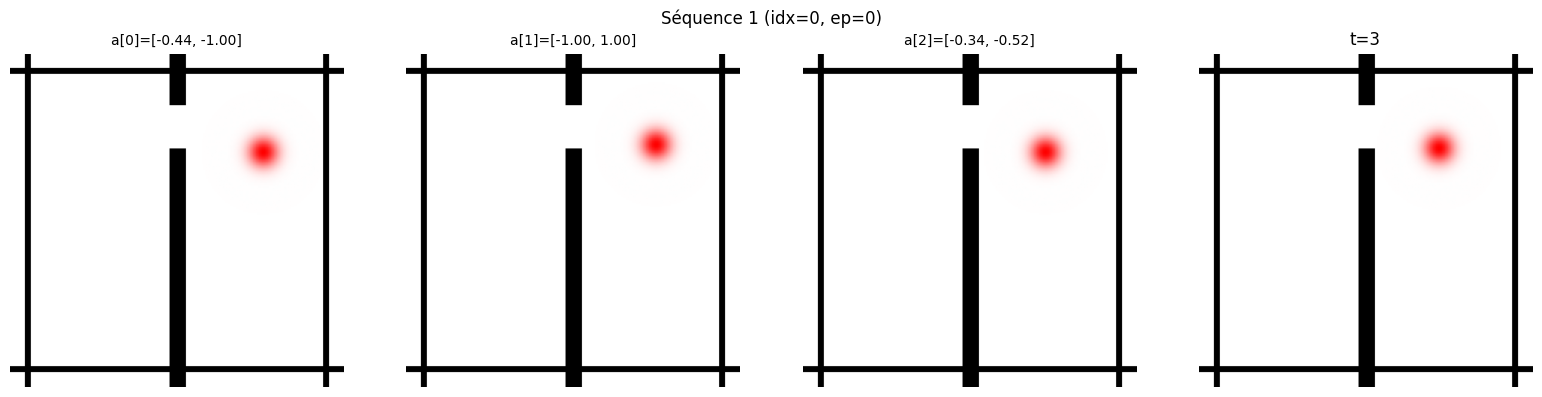


--- Échantillon 2 (index 29360) ---
Obs shape: torch.Size([4, 3, 224, 224]), dtype: torch.float32
  Min: -1.0000, Max: 1.0000
  Mean: 0.7692, Std: 0.6320
  Contains NaN: False
Actions shape: torch.Size([4, 2]), dtype: torch.float32
  Contenu: [[ 1.        -1.       ]
 [ 1.        -0.2740177]
 [ 1.        -0.2965674]
 [ 1.        -1.       ]]
  Min: -1.0000, Max: 1.0000
  Contains NaN: False


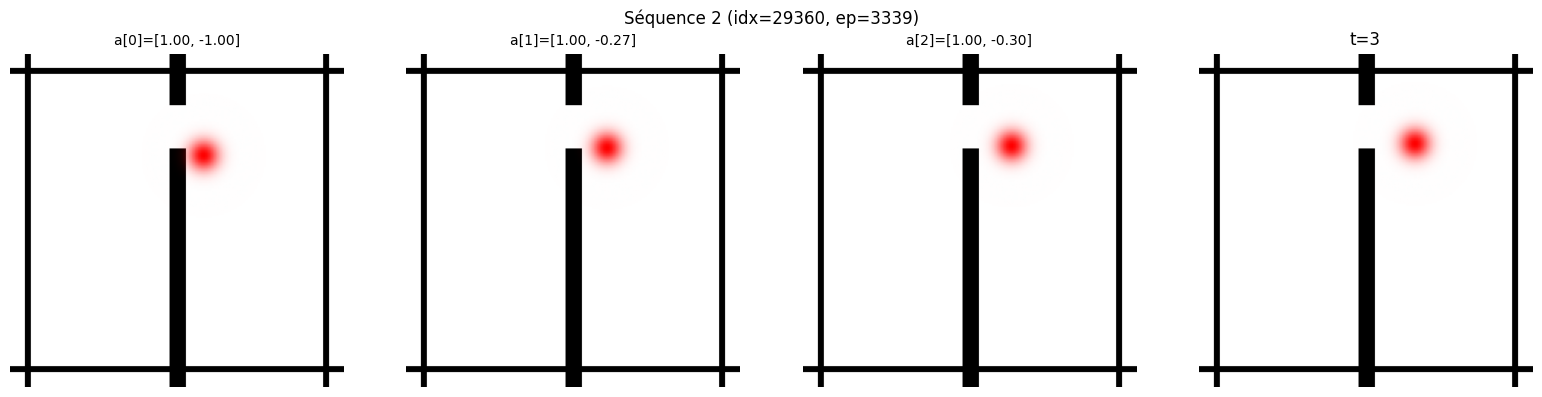


--- Échantillon 3 (index 58720) ---
Obs shape: torch.Size([4, 3, 224, 224]), dtype: torch.float32
  Min: -1.0000, Max: 1.0000
  Mean: 0.7691, Std: 0.6321
  Contains NaN: False
Actions shape: torch.Size([4, 2]), dtype: torch.float32
  Contenu: [[ 1.          1.        ]
 [ 1.         -0.14446604]
 [-1.         -1.        ]
 [ 0.27238077  0.6495385 ]]
  Min: -1.0000, Max: 1.0000
  Contains NaN: False


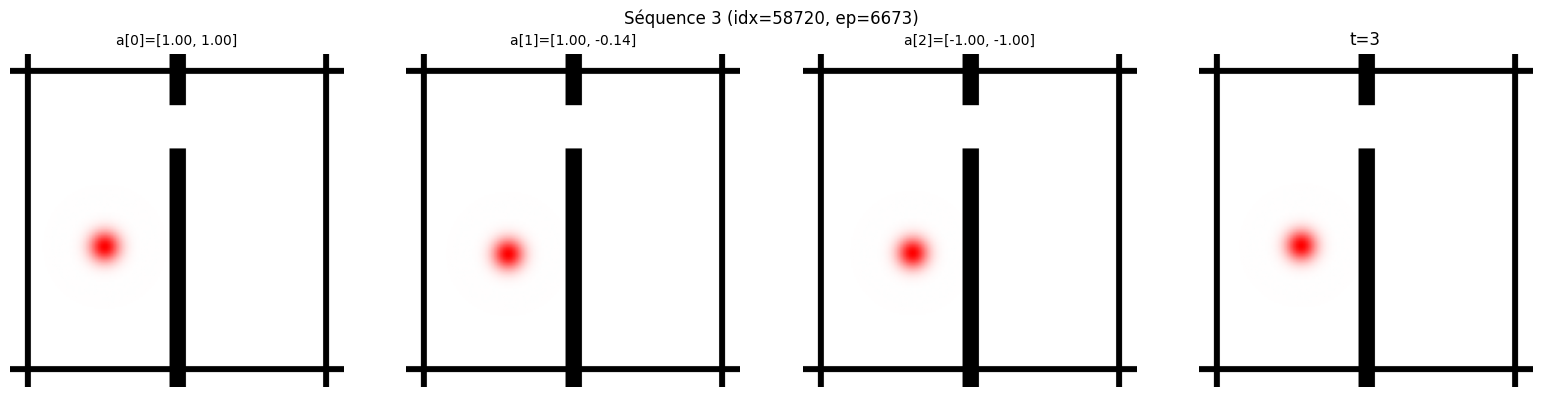


--- Échantillon 4 (index 88080) ---
Obs shape: torch.Size([4, 3, 224, 224]), dtype: torch.float32
  Min: -1.0000, Max: 1.0000
  Mean: 0.7695, Std: 0.6318
  Contains NaN: False
Actions shape: torch.Size([4, 2]), dtype: torch.float32
  Contenu: [[ 1.          1.        ]
 [ 1.         -1.        ]
 [ 1.          0.2145953 ]
 [ 1.          0.64549345]]
  Min: -1.0000, Max: 1.0000
  Contains NaN: False


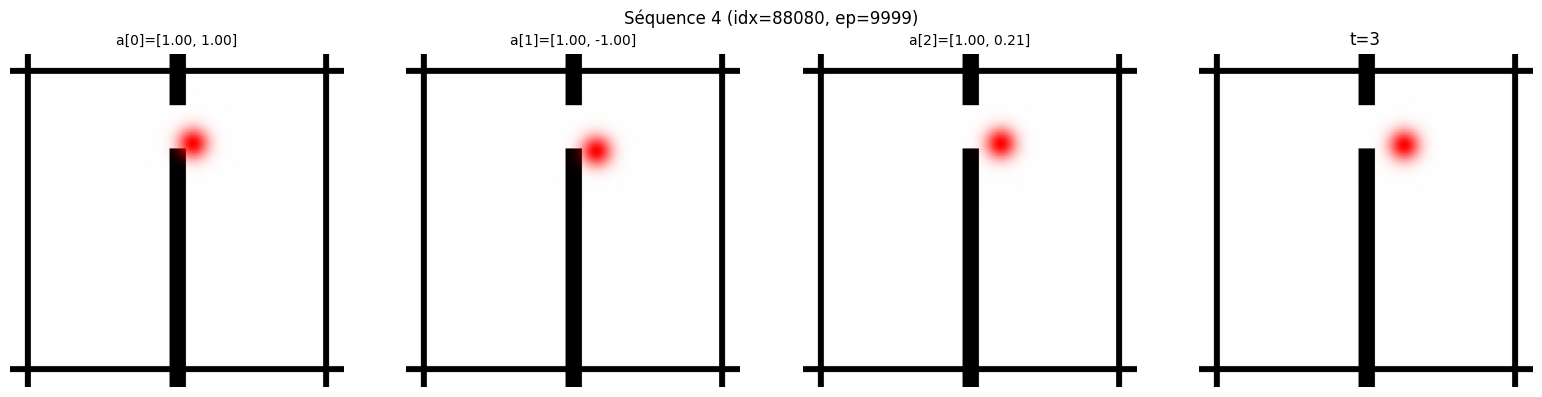


✓ Diagnostic terminé


In [ ]:
"""
Visualisation et diagnostic du dataset TwoRoom.
Vérifie : images OK, actions OK, pas de NaN, normalisation correcte, etc.
"""

import h5py
import hdf5plugin
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import transforms

TRAIN_ENC=False


class TwoRoomH5Dataset:
    def __init__(self, h5_path, seq_len=4, frame_skip=1, image_size=224,
                 subsample=10):
        self.h5_path = h5_path
        self.seq_len = seq_len
        self.frame_skip = frame_skip

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        with h5py.File(self.h5_path, 'r') as f:
            self.ep_idx = f['ep_idx'][:]
            self.actions_ok = np.isfinite(f['action'][:]).all(axis=-1)

        n_bad = int((~self.actions_ok).sum())
        print(f"[Dataset] {n_bad} pas de temps avec actions NaN/inf "
              f"({100 * n_bad / len(self.actions_ok):.2f}%)")

        self.num_samples = len(self.ep_idx)
        self.valid_indices = self._compute_valid_indices()[::subsample]
        print(f"[Dataset] {len(self.valid_indices)} fenêtres valides")

    def _compute_valid_indices(self):
        valid = []
        span = self.seq_len * self.frame_skip
        for i in range(self.num_samples - span):
            if (self.ep_idx[i] == self.ep_idx[i + span - 1]
                    and self.actions_ok[i:i + span].all()):
                valid.append(i)
        return valid

    @property
    def file(self):
        if not hasattr(self, '_file') or self._file is None:
            self._file = h5py.File(self.h5_path, 'r')
        return self._file

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        start_idx = self.valid_indices[idx]
        indices = [start_idx + i * self.frame_skip
                   for i in range(self.seq_len)]

        images, actions = [], []
        f = self.file
        for i in indices:
            img = self.transform(np.array(f['pixels'][i]))
            images.append(img)

            action_block = [f['action'][i + j]
                            for j in range(self.frame_skip)]
            actions.append(torch.tensor(np.array(action_block),
                                        dtype=torch.float32).flatten())

        return torch.stack(images), torch.stack(actions)


def inspect_hdf5_raw(h5_path):
    """Inspecte le fichier HDF5 brut (avant transformation)."""
    print("\n" + "="*70)
    print("INSPECTION DU FICHIER HDF5 BRUT")
    print("="*70)
    
    with h5py.File(h5_path, 'r') as f:
        print(f"\nClés du HDF5: {list(f.keys())}")
        
        if 'pixels' in f:
            pixels = f['pixels']
            print(f"\nPixels:")
            print(f"  Shape: {pixels.shape}, dtype: {pixels.dtype}")
            # h5py Datasets ne supportent pas .min() directement sur de gros datasets
            # On charge juste un échantillon pour inspecter
            sample_img = np.array(pixels[0])
            print(f"  Image 0: shape {sample_img.shape}, dtype {sample_img.dtype}")
            print(f"  Image 0 min/max: {sample_img.min()} / {sample_img.max()}")
        
        if 'action' in f:
            actions = f['action']
            print(f"\nActions:")
            print(f"  Shape: {actions.shape}, dtype: {actions.dtype}")
            actions_arr = np.array(actions[:])
            print(f"  Min: {actions_arr.min():.4f}, Max: {actions_arr.max():.4f}")
            has_nan = np.isnan(actions_arr).any()
            has_inf = np.isinf(actions_arr).any()
            print(f"  NaN: {has_nan}, Inf: {has_inf}")
            if has_nan or has_inf:
                count_nan = np.isnan(actions_arr).sum()
                count_inf = np.isinf(actions_arr).sum()
                print(f"    → NaN count: {count_nan}, Inf count: {count_inf}")
        
        if 'ep_idx' in f:
            ep_idx = f['ep_idx'][:]
            print(f"\nEpisodes:")
            print(f"  Index range: {ep_idx.min()}-{ep_idx.max()}")
            print(f"  Nombre d'épisodes uniques: {len(np.unique(ep_idx))}")
        
        if 'ep_len' in f:
            ep_len = f['ep_len'][:]
            print(f"\nLongueur des épisodes:")
            print(f"  Min: {ep_len.min()}, Max: {ep_len.max()}, "
                  f"Mean: {ep_len.mean():.1f}")


def visualize_dataset(h5_path, num_samples=4):
    """Affiche quelques séquences du dataset transformé."""
    print("\n" + "="*70)
    print("VISUALISATION DU DATASET TRANSFORMÉ")
    print("="*70)
    
    dataset = TwoRoomH5Dataset(h5_path, seq_len=4, frame_skip=1)
    
    # Sélectionne quelques indices spread dans le dataset
    indices = np.linspace(0, len(dataset) - 1, num_samples, dtype=int)
    
    for sample_num, idx in enumerate(indices):
        obs, actions = dataset[idx]
        
        print(f"\n--- Échantillon {sample_num + 1} (index {idx}) ---")
        print(f"Obs shape: {obs.shape}, dtype: {obs.dtype}")
        print(f"  Min: {obs.min():.4f}, Max: {obs.max():.4f}")
        print(f"  Mean: {obs.mean():.4f}, Std: {obs.std():.4f}")
        print(f"  Contains NaN: {torch.isnan(obs).any().item()}")
        
        print(f"Actions shape: {actions.shape}, dtype: {actions.dtype}")
        print(f"  Contenu: {actions.numpy()}")
        print(f"  Min: {actions.min():.4f}, Max: {actions.max():.4f}")
        print(f"  Contains NaN: {torch.isnan(actions).any().item()}")
        
        # Plot : 4 frames + actions pour le motion
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        ep_num = dataset.file["ep_idx"][dataset.valid_indices[idx]]
        fig.suptitle(f'Séquence {sample_num + 1} '
                     f'(idx={idx}, ep={ep_num})',
                     fontsize=12)
        
        for t in range(4):
            img = obs[t].permute(1, 2, 0).numpy()
            
            img = img * 0.5 + 0.5
            img = img.clip(0, 1)
            
            axes[t].imshow(img)
            axes[t].axis('off')
            
            if t < 3:
                action_vals = actions[t].numpy()
                action_str = f"a[{t}]=[{action_vals[0]:.2f}, {action_vals[1]:.2f}]"
                axes[t].set_title(action_str, fontsize=10)
            else:
                axes[t].set_title(f"t={t}")
        
        plt.tight_layout()
        plt.show()


def check_dataset_sanity(h5_path):
    """Vérifie la cohérence globale du dataset."""
    print("\n" + "="*70)
    print("VÉRIFICATION DE COHÉRENCE")
    print("="*70)
    
    dataset = TwoRoomH5Dataset(h5_path, seq_len=4, frame_skip=1)
    
    
    print("\nTest de 50 échantillons aléatoires...")
    indices = np.random.choice(len(dataset), min(50, len(dataset)), replace=False)
    
    errors = []
    for idx in indices:
        try:
            obs, actions = dataset[idx]
            
           
            assert obs.shape == (4, 3, 224, 224), f"Shape obs invalide: {obs.shape}"
            assert actions.shape == (4, 2), f"Shape actions invalide: {actions.shape}"
            assert torch.isfinite(obs).all(), "NaN/inf dans obs"
            assert torch.isfinite(actions).all(), "NaN/inf dans actions"
            assert obs.dtype == torch.float32, f"dtype obs: {obs.dtype}"
            
        except AssertionError as e:
            errors.append((idx, str(e)))
        except Exception as e:
            errors.append((idx, f"Exception: {type(e).__name__}: {e}"))
    
    if errors:
        print(f"❌ {len(errors)} erreur(s) détectée(s):")
        for idx, msg in errors[:5]:
            print(f"   Index {idx}: {msg}")
        if len(errors) > 5:
            print(f"   ... et {len(errors) - 5} de plus")
    else:
        print(f"✓ Tous les 50 échantillons OK")
    
    # Stats globales
    print("\nStatistiques globales du dataset:")
    print(f"  Taille: {len(dataset)} fenêtres")
    print(f"  Taille brute HDF5: {dataset.num_samples} pas de temps")
    print(f"  Actions NaN/inf: {(~dataset.actions_ok).sum()} / {len(dataset.actions_ok)}")
    pct_valid = 100 * len(dataset.valid_indices) / (dataset.num_samples - 3)
    print(f"  Fenêtres valides (après subsample=10): {len(dataset.valid_indices)}")
    print(f"  Pourcentage: {pct_valid:.2f}% (du brut - 3)")


h5_file = "tworoom.h5"

print(f"\n{'='*70}")
print(f"DIAGNOSTIC DU DATASET: {h5_file}")
print(f"{'='*70}")

inspect_hdf5_raw(h5_file)

check_dataset_sanity(h5_file)

visualize_dataset(h5_file, num_samples=4)

print("\n" + "="*70)
print("✓ Diagnostic terminé")
print("="*70)

In [ ]:


import h5py
import hdf5plugin  # nécessaire pour lire le HDF5 compressé
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import timm
from tqdm import tqdm



class Projector(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)
        self.bn = nn.BatchNorm1d(out_dim)

    def forward(self, x):
        return self.bn(self.fc(x))



class LeWMEncoder(nn.Module):
    def __init__(self, embed_dim=192):
        super().__init__()
        self.vit = timm.create_model('vit_tiny_patch16_224', pretrained=False,
                                     num_classes=0, global_pool='')
        self.projector = Projector(self.vit.num_features, embed_dim)

    def forward(self, obs):
        B, T, C, H, W = obs.shape
        x = obs.view(B * T, C, H, W)
        features = self.vit.forward_features(x)
        cls_token = features[:, 0]
        z = self.projector(cls_token)
        return z.view(B, T, -1)



class AdaLNBlock(nn.Module):
    def __init__(self, dim, nhead=8, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.attn = nn.MultiheadAttention(dim, nhead, dropout=dropout,
                                          batch_first=True)
        self.norm2 = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * mlp_ratio),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * mlp_ratio, dim),
            nn.Dropout(dropout),
        )
        self.adaLN = nn.Sequential(nn.SiLU(), nn.Linear(dim, 6 * dim))
        nn.init.zeros_(self.adaLN[-1].weight)
        nn.init.zeros_(self.adaLN[-1].bias)

    def forward(self, x, cond, attn_mask):
        s1, sc1, g1, s2, sc2, g2 = self.adaLN(cond).chunk(6, dim=-1)

        h = self.norm1(x) * (1 + sc1) + s1
        attn_out, _ = self.attn(h, h, h, attn_mask=attn_mask,
                                need_weights=False)
        x = x + g1 * attn_out

        h = self.norm2(x) * (1 + sc2) + s2
        x = x + g2 * self.mlp(h)
        return x



class LeWMPredictor(nn.Module):
    def __init__(self, embed_dim=192, action_dim=2, num_layers=4,
                 nhead=8, dropout=0.1, max_len=64):
        super().__init__()
        self.action_proj = nn.Linear(action_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, max_len, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        self.blocks = nn.ModuleList([
            AdaLNBlock(embed_dim, nhead=nhead, dropout=dropout)
            for _ in range(num_layers)
        ])
        self.projector = Projector(embed_dim, embed_dim)


    def forward(self, z, actions):
        B, T, D = z.shape
        cond = self.action_proj(actions)            
        x = z + self.pos_embed[:, :T]

        mask = torch.triu(torch.ones(T, T, dtype=torch.bool,
                                     device=z.device), diagonal=1)
        for blk in self.blocks:
            x = blk(x, cond, attn_mask=mask)

        out = self.projector(x.reshape(B * T, D))
        return out.view(B, T, D)



def epps_pulley_stat(h, t_nodes):
    """h : (T, B, M) ; t_nodes : (K,). Statistique EP moyennée sur T et M."""
    w = torch.exp(-t_nodes ** 2 / 2.0)
    phi_0 = torch.exp(-t_nodes ** 2 / 2.0)

    arg = h.unsqueeze(-1) * t_nodes               
    phi_real = torch.cos(arg).mean(dim=1)         
    phi_imag = torch.sin(arg).mean(dim=1)

    diff_sq = (phi_real - phi_0) ** 2 + phi_imag ** 2
    stats = torch.trapz(w * diff_sq, t_nodes, dim=-1)   
    return stats.mean()


def sigreg(z, num_projections=256, num_knots=17):
    """z : (B, T, D). Un test par pas de temps, sur la dimension batch."""
    z = z.float()  
    B, T, D = z.shape
    directions = torch.randn(D, num_projections, device=z.device,
                             dtype=torch.float32)
    directions = F.normalize(directions, p=2, dim=0)

    h = torch.einsum('btd,dm->tbm', z, directions)    
    t_nodes = torch.linspace(0.2, 4.0, steps=num_knots,
                             device=z.device, dtype=torch.float32)
    return epps_pulley_stat(h, t_nodes)



class LeWorldModel(nn.Module):
    def __init__(self, embed_dim=192, action_dim=2):
        super().__init__()
        self.encoder = LeWMEncoder(embed_dim)
        self.predictor = LeWMPredictor(embed_dim, action_dim)

    def forward(self, obs, actions):
        z = self.encoder(obs)
        next_z_pred = self.predictor(z, actions)
        return z, next_z_pred

    def loss(self, obs, actions, lambd=0.1):
        z, next_z_pred = self(obs, actions)
        pred_loss = F.mse_loss(next_z_pred[:, :-1].float(), z[:, 1:].float())
        sigreg_loss = sigreg(z)
        total_loss = pred_loss + lambd * sigreg_loss
        return total_loss, pred_loss, sigreg_loss, z


class LeWMDecoder(nn.Module):
    def __init__(self, embed_dim=192, hidden_dim=192, patch_size=16,
                 img_size=224, num_layers=4):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches_1d = img_size // patch_size
        self.num_patches = self.num_patches_1d ** 2

        self.kv_proj = nn.Linear(embed_dim, hidden_dim)
        self.query_tokens = nn.Parameter(
            torch.randn(1, self.num_patches, hidden_dim))

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_dim, nhead=4, dim_feedforward=hidden_dim * 4,
            dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerDecoder(decoder_layer,
                                                 num_layers=num_layers)
        self.out_proj = nn.Linear(hidden_dim, patch_size * patch_size * 3)

    def forward(self, z):
        B = z.shape[0]
        memory = self.kv_proj(z).unsqueeze(1)
        queries = self.query_tokens.expand(B, -1, -1)
        x = self.transformer(tgt=queries, memory=memory)
        patches = self.out_proj(x)

        P, N = self.patch_size, self.num_patches_1d
        patches = patches.view(B, N, N, 3, P, P)
        img = patches.permute(0, 3, 1, 4, 2, 5).contiguous() \
                     .view(B, 3, N * P, N * P)
        return img


class TwoRoomH5Dataset(Dataset):
    def __init__(self, h5_path, seq_len=4, frame_skip=1, image_size=224,
                 subsample=10):
        self.h5_path = h5_path
        self.seq_len = seq_len
        self.frame_skip = frame_skip
        self._file = None  

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        with h5py.File(self.h5_path, 'r') as f:
            self.ep_idx = f['ep_idx'][:]
            
            self.actions_ok = np.isfinite(f['action'][:]).all(axis=-1)

        n_bad = int((~self.actions_ok).sum())
        print(f"{n_bad} pas de temps avec actions NaN/inf "
              f"({100 * n_bad / len(self.actions_ok):.2f}%) — exclus")

        self.num_samples = len(self.ep_idx)
        self.valid_indices = self._compute_valid_indices()[::subsample]
        print(f"{len(self.valid_indices)} fenêtres valides")

    def _compute_valid_indices(self):
        valid = []
        span = self.seq_len * self.frame_skip
        for i in range(self.num_samples - span):

            if (self.ep_idx[i] == self.ep_idx[i + span - 1]
                    and self.actions_ok[i:i + span].all()):
                valid.append(i)
        return valid

    @property
    def file(self):
        if self._file is None:
            self._file = h5py.File(self.h5_path, 'r')
        return self._file

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        start_idx = self.valid_indices[idx]
        indices = [start_idx + i * self.frame_skip
                   for i in range(self.seq_len)]

        images, actions = [], []
        f = self.file
        for i in indices:
            img = self.transform(np.array(f['pixels'][i]))
            images.append(img)

            action_block = [f['action'][i + j]
                            for j in range(self.frame_skip)]
            actions.append(torch.tensor(np.array(action_block),
                                        dtype=torch.float32).flatten())

        return torch.stack(images), torch.stack(actions)



@torch.no_grad()
def plot_predictions(model, decoder, test_loader, device, horizon=3):
    import matplotlib.pyplot as plt

    model.eval()
    decoder.eval()

    obs, actions = next(iter(test_loader))
    obs, actions = obs.to(device), actions.to(device)
    B, T, C, H, W = obs.shape

    z = model.encoder(obs)
    z_history = z[:, :1]

    for t in range(horizon):
        current_actions = actions[:, :t + 1]
        next_z_pred = model.predictor(z_history, current_actions)
        z_history = torch.cat([z_history, next_z_pred[:, -1:]], dim=1)

    flat_latents = z_history[0].view(-1, z_history.size(-1))
    pred_images = decoder(flat_latents).view(horizon + 1, C, H, W)

    fig, axes = plt.subplots(2, horizon + 1, figsize=(3 * (horizon + 1), 6))
    for t in range(horizon + 1):
        gt = (obs[0, t].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
        axes[0, t].imshow(gt)
        axes[0, t].axis('off')
        axes[0, t].set_title(f"Truth (t={t})")

        pr = (pred_images[t].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
        axes[1, t].imshow(pr)
        axes[1, t].axis('off')
        axes[1, t].set_title("Decoded (t=0)" if t == 0 else f"Predicted (t={t})")

    plt.tight_layout()
    plt.show()




h5_file = "tworoom.h5"

dataset = TwoRoomH5Dataset(h5_file, seq_len=4, frame_skip=1)
dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)


indices = list(range(dataset_size))
train_indices = indices[:train_size]
test_indices = indices[train_size:]


train_dataset = Subset(dataset, train_indices)
test_dataset = Subset(dataset, test_indices)

print(f"Dataset total : {dataset_size} séquences")
print(f" -> Train : {len(train_dataset)} séquences")
print(f" -> Test  : {len(test_dataset)} séquences")


train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,
                          drop_last=True, num_workers=0, pin_memory=True)

# shuffle=False est la norme pour l'évaluation afin d'avoir des résultats constants
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False,
                         drop_last=True, num_workers=0, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Mixed precision bf16 si supporté (Ampere+) — SIGReg reste en fp32
use_bf16 = (device.type == 'cuda' and torch.cuda.is_bf16_supported())
print(f"bf16 autocast: {use_bf16}")

action_dim = 2
model = LeWorldModel(embed_dim=192, action_dim=action_dim).to(device)
decoder = LeWMDecoder(embed_dim=192, img_size=224).to(device)

optimizer_wm = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
optimizer_dec = optim.AdamW(decoder.parameters(), lr=1e-4)

warmup_steps = 1000
scheduler_wm = optim.lr_scheduler.LambdaLR(
    optimizer_wm, lambda step: min(1.0, (step + 1) / warmup_steps))
if TRAIN_ENC :
    epochs_wm = 20
    lambd = 0.1

    
    for epoch in range(epochs_wm):
        model.train()
        total_wm_loss = total_pred = total_reg = 0.0
        skipped = 0

        pbar = tqdm(train_loader, desc=f"WM Epoch {epoch+1}/{epochs_wm}",
                    unit="batch")
        for obs, actions in pbar:
            obs = obs.to(device, non_blocking=True)
            actions = actions.to(device, non_blocking=True)

            optimizer_wm.zero_grad()
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16,
                                enabled=use_bf16):
                loss_wm, pred_loss, reg_loss, _ = model.loss(obs, actions,
                                                                lambd)
            loss_wm.backward()

            
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(),
                                                        max_norm=1.0)
            if torch.isfinite(grad_norm):
                optimizer_wm.step()
            else:
                optimizer_wm.zero_grad()
                skipped += 1
            scheduler_wm.step()

            total_wm_loss += loss_wm.item()
            total_pred += pred_loss.item()
            total_reg += reg_loss.item()
            pbar.set_postfix({'pred': f"{pred_loss.item():.4f}",
                                'sigreg': f"{reg_loss.item():.4f}"})

        n = len(train_loader)
        msg = (f"Epoch {epoch+1} | Loss: {total_wm_loss/n:.4f} | "
                f"Pred: {total_pred/n:.4f} | SIGReg: {total_reg/n:.4f}")
        if skipped:
            msg += f" | steps sautés (grad non fini): {skipped}"
        print(msg)
        torch.save(model.state_dict(), 'lewm_model_tworoom.pth')

model.load_state_dict(torch.load("lewm_model_tworoom.pth",  weights_only=True))





10000 pas de temps avec actions NaN/inf (1.09%) — exclus
88081 fenêtres valides
cuda
bf16 autocast: True


Cache estimé: 212.4 GB | RAM dispo: 11.3 GB
→ Mode STREAMING (économe en RAM)


Decoder Epoch 1/19: 100%|██████████| 688/688 [52:04<00:00,  4.54s/it, loss=0.0091] 


Decoder Epoch 1 | Loss: 0.0126


Decoder Epoch 2/19: 100%|██████████| 688/688 [50:20<00:00,  4.39s/it, loss=0.0071]


Decoder Epoch 2 | Loss: 0.0081


...

Decoder Epoch 17 | Loss: 0.0024


Decoder Epoch 18/19: 100%|██████████| 688/688 [56:40<00:00,  4.94s/it, loss=0.0017]


Decoder Epoch 18 | Loss: 0.0023


Decoder Epoch 19/19: 100%|██████████| 688/688 [56:54<00:00,  4.96s/it, loss=0.0021]


Decoder Epoch 19 | Loss: 0.0022


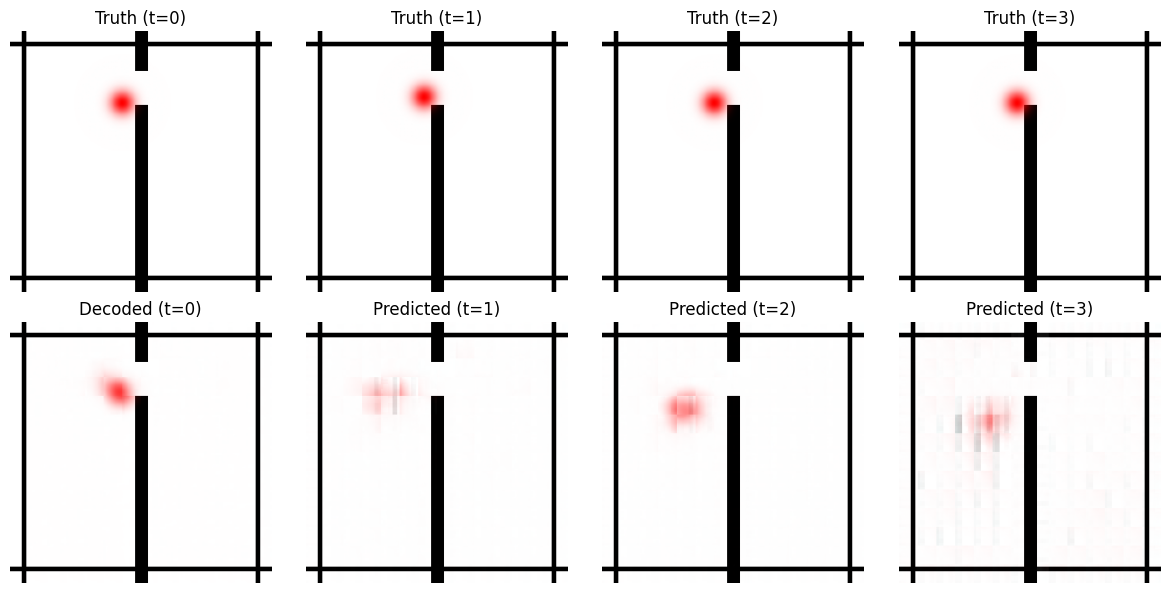

In [ ]:
from torch.amp import GradScaler, autocast

def train_decoder_cached(decoder, optimizer_dec, scaler, cached, epochs_dec, device):
    for epoch in range(epochs_dec):
        decoder.train()
        total = 0.0
        pbar = tqdm(cached, desc=f"Decoder Epoch {epoch+1}/{epochs_dec}", leave=True)
        for z_flat, obs_flat in pbar:
            z_flat = z_flat.to(device, non_blocking=True)
            obs_flat = obs_flat.to(device, non_blocking=True)
            optimizer_dec.zero_grad()
            with autocast(device_type="cuda"):
                recon = decoder(z_flat)
                loss = F.mse_loss(recon, obs_flat)
            scaler.scale(loss).backward()
            scaler.step(optimizer_dec); scaler.update()
            total += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        print(f"Decoder Epoch {epoch+1} | Loss: {total/len(cached):.4f}")
        torch.save(decoder.state_dict(), 'lewm_decoder_tworoom.pth')


def train_decoder_streaming(decoder, model, optimizer_dec, scaler,
                            loader, epochs_dec, device):
    for epoch in range(epochs_dec):
        decoder.train()
        total = 0.0
        pbar = tqdm(loader, desc=f"Decoder Epoch {epoch+1}/{epochs_dec}", leave=True)
        for obs, _ in pbar:
            obs = obs.to(device, non_blocking=True)
            with torch.no_grad(), autocast(device_type="cuda"):
                z = model.encoder(obs)
            B, T, D = z.shape
            z_flat = z.reshape(B*T, D)
            obs_flat = obs.reshape(B*T, 3, 224, 224)
            optimizer_dec.zero_grad()
            with autocast(device_type="cuda"):
                recon = decoder(z_flat)
                loss = F.mse_loss(recon, obs_flat)
            scaler.scale(loss).backward()
            scaler.step(optimizer_dec); scaler.update()
            total += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        print(f"Decoder Epoch {epoch+1} | Loss: {total/len(loader):.4f}")
        torch.save(decoder.state_dict(), 'lewm_decoder_tworoom.pth')



decoder.load_state_dict(torch.load("lewm_decoder_tworoom.pth", weights_only=True))
epochs_dec = 19
model.eval()
scaler = GradScaler("cuda")

# --- Décide AVANT de cacher : la taille tient-elle en RAM ? ----------
import psutil
n_imgs = len(train_dataset) * train_dataset.seq_len
bytes_per_img = 3 * 224 * 224 * 4          # obs en float32
bytes_per_z = 192 * 4                        # latent (négligeable)
est_gb = n_imgs * (bytes_per_img + bytes_per_z) / 1e9
avail_gb = psutil.virtual_memory().available / 1e9
print(f"Cache estimé: {est_gb:.1f} GB | RAM dispo: {avail_gb:.1f} GB")

# garde une marge de sécurité (70 % de la RAM dispo)
can_cache = est_gb < 0.7 * avail_gb

if can_cache:
    print("→ Mode CACHE (rapide)")
    cached = []
    with torch.no_grad(), autocast(device_type="cuda"):
        for obs, _ in tqdm(train_loader, desc="Pré-encodage"):
            obs = obs.to(device, non_blocking=True)
            z = model.encoder(obs)
            B, T, D = z.shape
            cached.append((z.reshape(B*T, D).cpu(),
                            obs.reshape(B*T, 3, 224, 224).cpu()))
    del train_loader
    torch.cuda.empty_cache()
    train_decoder_cached(decoder, optimizer_dec, scaler, cached, epochs_dec, device)
else:
    print("→ Mode STREAMING (économe en RAM)")
    train_decoder_streaming(decoder, model, optimizer_dec, scaler,
                            train_loader, epochs_dec, device)


plot_predictions(model, decoder, test_loader, device, horizon=3)

In [4]:
h5_file = "tworoom.h5"
train_dataset = TwoRoomH5Dataset(h5_file, seq_len=4, frame_skip=1)
for k in range(0, len(train_dataset), max(1, len(train_dataset) // 200)):
    obs, act = train_dataset[k]
    if not torch.isfinite(obs).all():
        print(f"NaN/inf dans obs à l'index {k}")
    if not torch.isfinite(act).all():
        print(f"NaN/inf dans actions à l'index {k}")
print("scan terminé")

10000 pas de temps avec actions NaN/inf (1.09%) — exclus
88081 fenêtres valides
scan terminé
